In [1]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob
import json
import os

In [2]:
target_size=(512,512)

In [3]:
# list all image paths
image_dir = "../../../data/raw/train/images/"
image_files = glob.glob(image_dir + "*")
print(len(image_files))
print(image_files[:5])

60578
['../../../data/raw/train/images/45df1fe3293b.jpg', '../../../data/raw/train/images/b2ab3b743d4e.jpg', '../../../data/raw/train/images/51d3b1a6baf3.jpg', '../../../data/raw/train/images/a9e9ce9277c1.jpg', '../../../data/raw/train/images/7f1f545fe081.jpg']


In [4]:
# list all annotation files paths

annotations_dir="../../../data/raw/train/annotations/"
annotations_files=glob.glob(annotations_dir+"*")
print(len(annotations_files))
print(annotations_files[:5])

60578
['../../../data/raw/train/annotations/e91e28111e86.json', '../../../data/raw/train/annotations/75c0449f6917.json', '../../../data/raw/train/annotations/66dd2a250237.json', '../../../data/raw/train/annotations/58595c30beab.json', '../../../data/raw/train/annotations/497a547454d7.json']


In [5]:
# line image
search_string = "0a0a78fc8d65"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/raw/train/images/0a0a78fc8d65.jpg']
['../../../data/raw/train/annotations/0a0a78fc8d65.json']


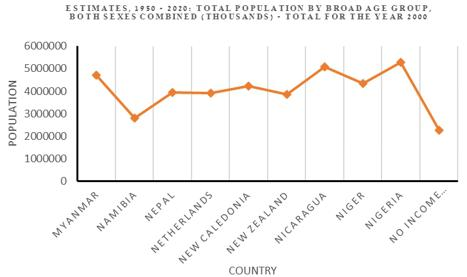

In [6]:
Image.open(fp=matched_image_path[0])

In [7]:
# check the raw image size

with Image.open(fp=matched_image_path[0]) as img:
    width, height=img.size

print('width:', width)
print('height:', height)

width: 467
height: 277


In [8]:
def image_markable(annotation_path: str, image_path: str) -> np.array:
    '''
    Mark all the available information in the annotation.json on the corresponding image file.

    Params:
        annotation_path: the path of annotation file
        image_path: the path of the image file

    Return:
        numpy.ndarray (image with annotations)
    '''
    with open(annotation_path, "r") as f:
        annotation = json.load(f)

    # load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Error: Unable to load image at {image_path}")
        return None

    print(f"✅ Image loaded: {image.shape}")

    # missing elements in annotation file
    missing_elements = []

    # ----------------------  mark main body of the image (plot-bb) ----------------------
    plot_bb = annotation.get("plot-bb")
    if plot_bb:
        # get the vertex to determine the boundary
        x0, y0, width, height = plot_bb["x0"], plot_bb["y0"], plot_bb["width"], plot_bb["height"]
        cv2.rectangle(image, (x0, y0), (x0 + width, y0 + height), (255, 0, 0), 2)
    else:
        missing_elements.append("plot-bb")

    # ----------------------  mark tick location on x or y axes (ticks) ----------------------
    # use green dot to represent
    if "axes" in annotation:
        for axis in ["x-axis", "y-axis"]:
            if axis in annotation["axes"]:
                for tick in annotation["axes"][axis].get("ticks", []):
                    tick_x, tick_y = tick["tick_pt"]["x"], tick["tick_pt"]["y"]
                    cv2.circle(image, (tick_x, tick_y), 5, (0, 255, 0), -1)
            else:
                missing_elements.append(f"{axis} ticks")
    else:
        missing_elements.append("axes")

    # ----------------------  mark the points location on line graph (data-series) ----------------------
    if "visual-elements" in annotation:
        elements = annotation["visual-elements"]

        # `lines` 
        # red dot
        if "lines" in elements and elements["lines"]:
            for line in elements["lines"]:
                for data_point in line:
                    x, y = int(data_point["x"]), int(data_point["y"])
                    cv2.circle(image, (x, y), 7, (0, 0, 255), -1) 

        # `scatter points` 
        # light blue
        if "scatter points" in elements and elements["scatter points"]:
            for scatter in elements["scatter points"]:
                for point in scatter:
                    x, y = int(point["x"]), int(point["y"])
                    cv2.circle(image, (x, y), 6, (255, 165, 0), -1) 

        # `bars`
        # light yellow
        if "bars" in elements and elements["bars"]:
            for bar in elements["bars"]:
                x0, y0 = int(bar["x0"]), int(bar["y0"])  
                width, height = int(bar["width"]), int(bar["height"])
                x1, y1 = x0 + width, y0 + height  
                cv2.rectangle(image, (x0, y0), (x1, y1), (0, 255, 255), -1) 

        # `boxplots`
        if "boxplots" in elements and elements["boxplots"]:
            for box in elements["boxplots"]:
                x, y = int(box["x"]), int(box["y"])
                cv2.rectangle(image, (x - 5, y - 5), (x + 5, y + 5), (255, 0, 255), 2) 

        if "dot points" in elements and elements["dot points"]:
            for dot in elements["dot points"]:
                for point in dot:
                    x, y = int(point["x"]), int(point["y"])
                    cv2.circle(image, (x, y), 6, (255, 165, 50), -1) 
    else:
        missing_elements.append("visual-elements")

    # ----------------------  `data-series` ----------------------
    if "data-series" in annotation:
        for series in annotation["data-series"]:
            x_value = series.get("x", "Unknown")
            y_value = series.get("y", "Unknown")
            # print(f"Data point: {x_value} -> {y_value}")
    else:
        missing_elements.append("data-series")

    # ---------------------- mark the text region (text) ----------------------
    # use purple frame to represent
    if "text" in annotation:
        for text_item in annotation["text"]:
            polygon = text_item.get("polygon")
            if polygon:
                x0, y0 = polygon["x0"], polygon["y0"]
                x2, y2 = polygon["x2"], polygon["y2"]
                cv2.rectangle(image, (x0, y0), (x2, y2), (200, 50, 100), 2)
            else:
                missing_elements.append(f"text id {text_item.get('id', 'unknown')} missing polygon")
    else:
        missing_elements.append("text")

    # ---------------------- 5️⃣ output missing elements ----------------------
    if missing_elements:
        print("⚠️ Missing elements in annotation:", ", ".join(set(missing_elements)))

    return image

✅ Image loaded: (277, 467, 3)


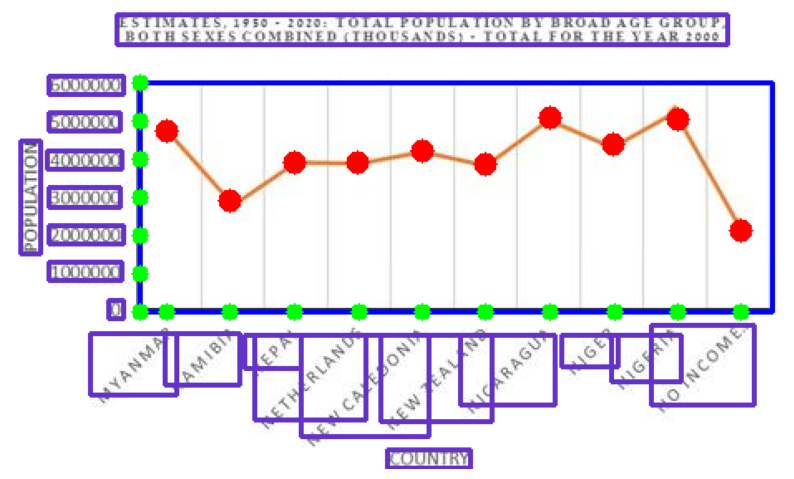

In [9]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

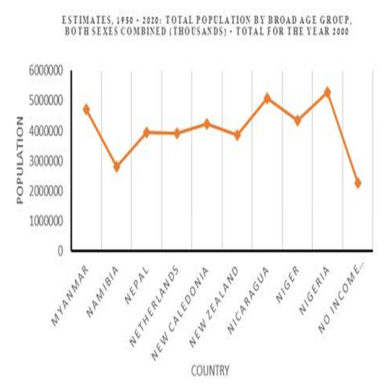

width: 512
height: 512


In [10]:
# resize the raw image to 512, 512
image = Image.open(fp=matched_image_path[0])
resized_image = image.resize(target_size, Image.LANCZOS)

plt.imshow(resized_image)
plt.axis("off")
plt.show()


width,height=resized_image.size
print('width:', width)
print('height:', height)

# tempory store the resized image
resized_image.save("./temp/0a0a78fc8d65.jpg")

✅ Image loaded: (512, 512, 3)


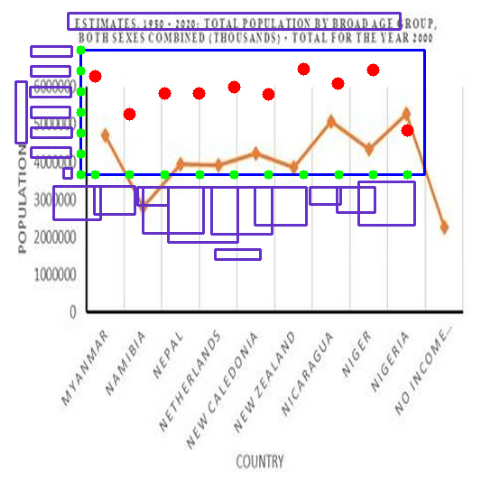

In [11]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path="./temp/0a0a78fc8d65.jpg")

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

$$

\text{scale}x = \frac{W{new}}{W_{orig}}
\\

\text{scale}y = \frac{H{new}}{H_{orig}}

\\
x{\prime} = x \times \text{scale}_x
\\

y{\prime} = y \times \text{scale}_y

$$

In [12]:
# because we resize the image, the ticks in the annotation cannot match the location
# I test scaling annotation value here to check if it works. 
with Image.open(fp=matched_image_path[0]) as img:
    width_ori, height_ori=img.size

print('width:', width_ori)
print('height:', height_ori)

with Image.open(fp="./temp/0a0a78fc8d65.jpg") as img:
    width_new, height_new=img.size

print('width:', width_new)
print('height:', height_new)

scale_x = width_new / width_ori
scale_y = height_new / height_ori

with open(matched_annotation_path[0],"r") as f:
    annotation=json.load(f)

# do not do modification on raw json file
updated_annotation = annotation.copy()

# update plot-bb
updated_annotation['plot-bb']['height']=int(updated_annotation['plot-bb']['height']*scale_y)
updated_annotation['plot-bb']['width']=int(updated_annotation['plot-bb']['width']*scale_x)
updated_annotation['plot-bb']['y0']=int(updated_annotation['plot-bb']['y0']*scale_y)
updated_annotation['plot-bb']['x0']=int(updated_annotation['plot-bb']['x0']*scale_x)
# update text ticks
for item in updated_annotation["text"]:
    polygon = item["polygon"]

    polygon["x0"] = int(polygon["x0"] * scale_x)
    polygon["x1"] = int(polygon["x1"] * scale_x)
    polygon["x2"] = int(polygon["x2"] * scale_x)
    polygon["x3"] = int(polygon["x3"] * scale_x)

    polygon["y0"] = int(polygon["y0"] * scale_y)
    polygon["y1"] = int(polygon["y1"] * scale_y)
    polygon["y2"] = int(polygon["y2"] * scale_y)
    polygon["y3"] = int(polygon["y3"] * scale_y)

# axes
for axis in ["x-axis", "y-axis"]:
    if axis in updated_annotation["axes"] and "ticks" in updated_annotation["axes"][axis]:
        for tick in updated_annotation["axes"][axis]["ticks"]:
            tick_pt = tick["tick_pt"]
            tick_pt["x"] = int(tick_pt["x"] * scale_x)
            tick_pt["y"] = int(tick_pt["y"] * scale_y)

# elements
for elements in updated_annotation['visual-elements']:
    if len(updated_annotation['visual-elements'][elements])!=0:
        for ticks in updated_annotation['visual-elements'][elements]:
            for tick in ticks:
                # print(tick['x'])
                tick['x']=tick['x']*scale_x
                tick['y']=tick['y']*scale_y

# data series
for data in updated_annotation['data-series']:
    if isinstance(data['x'], str):
        data['y']=data['y']*scale_y
    elif isinstance(data['y'], str):
        data['x']=data['x']*scale_x
    else:
        data['x']=data['x']*scale_x
        data['y']=data['y']*scale_y

print(updated_annotation)

width: 467
height: 277
width: 512
height: 512
{'source': 'generated', 'chart-type': 'line', 'plot-bb': {'height': 255, 'width': 417, 'x0': 85, 'y0': 81}, 'text': [{'id': 0, 'polygon': {'x0': 70, 'x1': 473, 'x2': 473, 'x3': 70, 'y0': 5, 'y1': 5, 'y2': 38, 'y3': 38}, 'text': 'ESTIMATES, 1950 - 2020 TOTAL POPULATION BY BROAD AGE GROUP, BOTH SEXES COMBINED (THOUSANDS) - TOTAL FOR THE YEAR 2000', 'role': 'chart_title'}, {'id': 1, 'polygon': {'x0': 248, 'x1': 303, 'x2': 303, 'x3': 248, 'y0': 489, 'y1': 489, 'y2': 510, 'y3': 510}, 'text': 'COUNTRY', 'role': 'axis_title'}, {'id': 2, 'polygon': {'x0': 6, 'x1': 19, 'x2': 19, 'x3': 6, 'y0': 146, 'y1': 146, 'y2': 271, 'y3': 271}, 'text': 'POPULATION', 'role': 'axis_title'}, {'id': 3, 'polygon': {'x0': 25, 'x1': 74, 'x2': 74, 'x3': 25, 'y0': 73, 'y1': 73, 'y2': 94, 'y3': 94}, 'text': '6000000', 'role': 'tick_label'}, {'id': 4, 'polygon': {'x0': 25, 'x1': 72, 'x2': 72, 'x3': 25, 'y0': 114, 'y1': 114, 'y2': 134, 'y3': 134}, 'text': '5000000', 'role':

In [13]:
with open('./temp/0a0a78fc8d65.json', "w") as f:
    json.dump(updated_annotation, f, indent=4)

✅ Image loaded: (512, 512, 3)


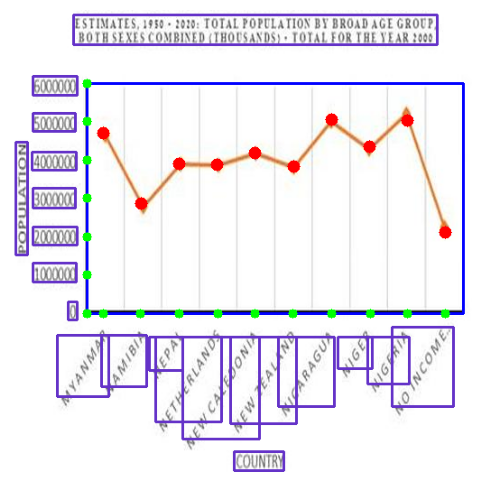

In [14]:
image=image_markable(annotation_path='./temp/0a0a78fc8d65.json',image_path="./temp/0a0a78fc8d65.jpg")

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [15]:
def annotation_resize(ori_image_path:str,origin_annotation_path:str,saved_path:str,resized_w_h: tuple=(512,512)):
    '''
    scaling the annotation json file values when the corresponding image size changes
    Params:
        ori_image_path: the path of original image
        origin_annotation_path: the path of the original annotation file
        saved path: the path where the updated annotation file should be saved
        resized_w_h: (width,height)
    '''
    origin_image=Image.open(fp=ori_image_path)
    width_ori, height_ori=origin_image.size

    width_new, height_new=resized_w_h

    scale_x = width_new / width_ori
    scale_y = height_new / height_ori

    with open(origin_annotation_path,"r") as f:
        annotation=json.load(f)

    # do not do modification on raw json file
    updated_annotation = annotation.copy()

    # update plot-bb
    updated_annotation['plot-bb']['height']=int(updated_annotation['plot-bb']['height']*scale_y)
    updated_annotation['plot-bb']['width']=int(updated_annotation['plot-bb']['width']*scale_x)
    updated_annotation['plot-bb']['y0']=int(updated_annotation['plot-bb']['y0']*scale_y)
    updated_annotation['plot-bb']['x0']=int(updated_annotation['plot-bb']['x0']*scale_x)
    # update text ticks
    for item in updated_annotation["text"]:
        polygon = item["polygon"]

        polygon["x0"] = int(polygon["x0"] * scale_x)
        polygon["x1"] = int(polygon["x1"] * scale_x)
        polygon["x2"] = int(polygon["x2"] * scale_x)
        polygon["x3"] = int(polygon["x3"] * scale_x)

        polygon["y0"] = int(polygon["y0"] * scale_y)
        polygon["y1"] = int(polygon["y1"] * scale_y)
        polygon["y2"] = int(polygon["y2"] * scale_y)
        polygon["y3"] = int(polygon["y3"] * scale_y)

    # axes
    for axis in ["x-axis", "y-axis"]:
        if axis in updated_annotation["axes"] and "ticks" in updated_annotation["axes"][axis]:
            for tick in updated_annotation["axes"][axis]["ticks"]:
                tick_pt = tick["tick_pt"]
                tick_pt["x"] = int(tick_pt["x"] * scale_x)
                tick_pt["y"] = int(tick_pt["y"] * scale_y)

    # elements
    for elements in updated_annotation['visual-elements']:
        # print(elements)
        if len(updated_annotation['visual-elements'][elements])!=0:
            if elements=='bars':
                for ticks in updated_annotation['visual-elements'][elements]:
                    # print(ticks)
                    ticks['width']=ticks['width']*scale_x
                    ticks['height']=ticks['height']*scale_y
                    ticks['x0']=ticks['x0']*scale_x
                    ticks['y0']=ticks['y0']*scale_y
            else:
                for ticks in updated_annotation['visual-elements'][elements]:
                    # print(ticks)
                    for tick in ticks:
                        # print(tick['x'])
                        tick['x']=tick['x']*scale_x
                        tick['y']=tick['y']*scale_y

    # data series
    for data in updated_annotation['data-series']:
        if isinstance(data['x'], str):
            data['y']=data['y']*scale_y
        elif isinstance(data['y'], str):
            data['x']=data['x']*scale_x
        else:
            data['x']=data['x']*scale_x
            data['y']=data['y']*scale_y

    with open(saved_path, "w") as f:
        json.dump(updated_annotation, f, indent=4)

    return
    

In [16]:
# scatter plot
search_string = "0a0ef43669cd"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/raw/train/images/0a0ef43669cd.jpg']
['../../../data/raw/train/annotations/0a0ef43669cd.json']


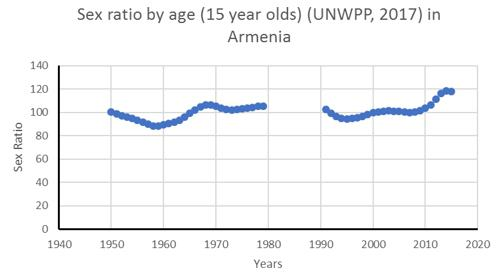

In [17]:
Image.open(fp=matched_image_path[0])

✅ Image loaded: (272, 498, 3)


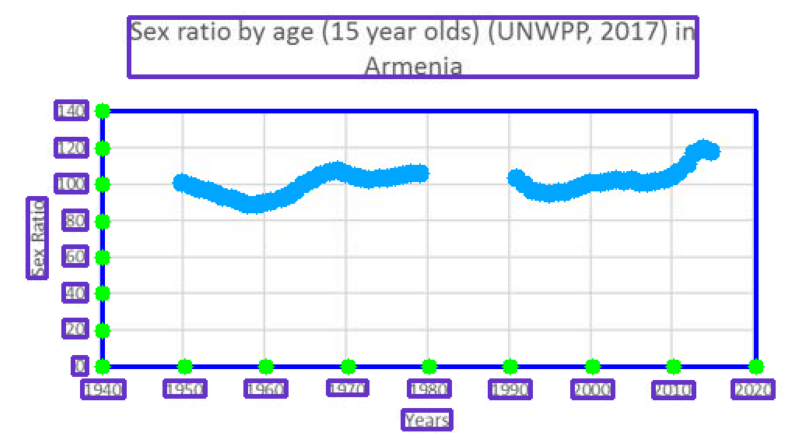

In [18]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

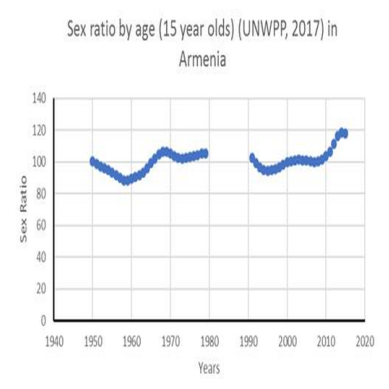

width: 512
height: 512


In [19]:
# resize the raw image to 512, 512
image = Image.open(fp=matched_image_path[0])
resized_image = image.resize(target_size, Image.LANCZOS)

plt.imshow(resized_image)
plt.axis("off")
plt.show()


width,height=resized_image.size
print('width:', width)
print('height:', height)

# tempory store the resized image
resized_image.save("./temp/0a0ef43669cd.jpg")

✅ Image loaded: (512, 512, 3)


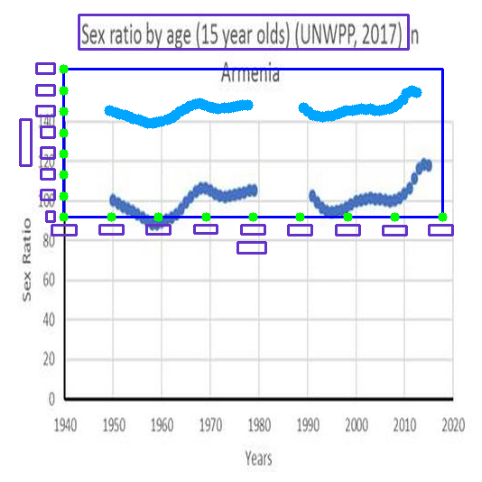

In [20]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path="./temp/0a0ef43669cd.jpg")

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [21]:
# scaling the corresponding annotation

annotation_resize(ori_image_path=matched_image_path[0],
                  origin_annotation_path=matched_annotation_path[0],
                  saved_path="./temp/0a0ef43669cd.json")

✅ Image loaded: (512, 512, 3)


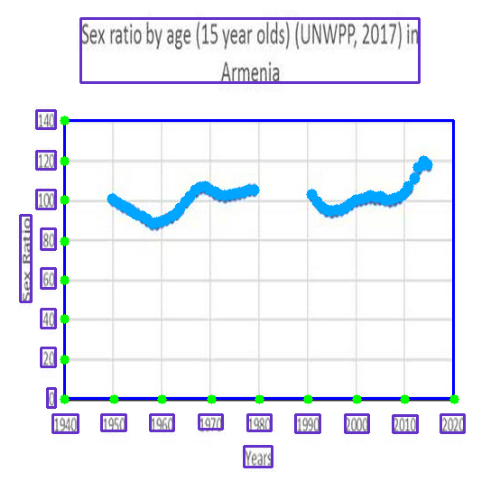

In [22]:
image=image_markable(annotation_path='./temp/0a0ef43669cd.json',image_path="./temp/0a0ef43669cd.jpg")

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [23]:
# vertical bar
search_string = "0b4dac8d0a28"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/raw/train/images/0b4dac8d0a28.jpg']
['../../../data/raw/train/annotations/0b4dac8d0a28.json']


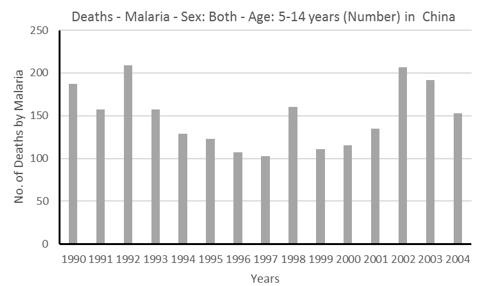

In [24]:
Image.open(fp=matched_image_path[0])

✅ Image loaded: (286, 481, 3)


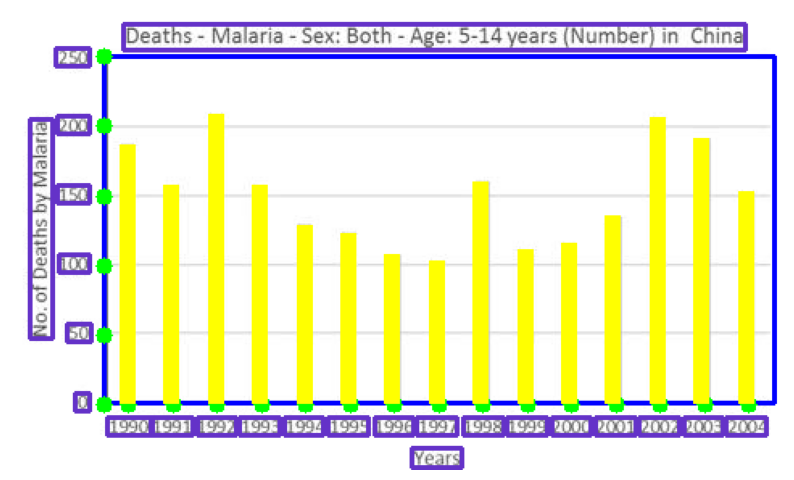

In [25]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

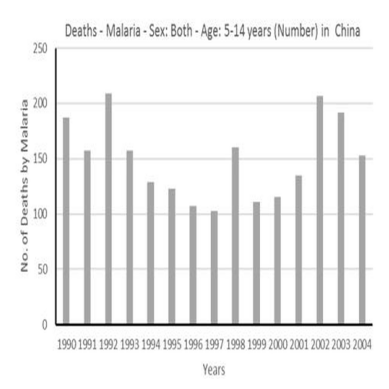

width: 512
height: 512


In [26]:
# resize the raw image to 512, 512
image = Image.open(fp=matched_image_path[0])
resized_image = image.resize(target_size, Image.LANCZOS)

plt.imshow(resized_image)
plt.axis("off")
plt.show()


width,height=resized_image.size
print('width:', width)
print('height:', height)

# tempory store the resized image
resized_image.save("./temp/0b4dac8d0a28.jpg")

✅ Image loaded: (512, 512, 3)


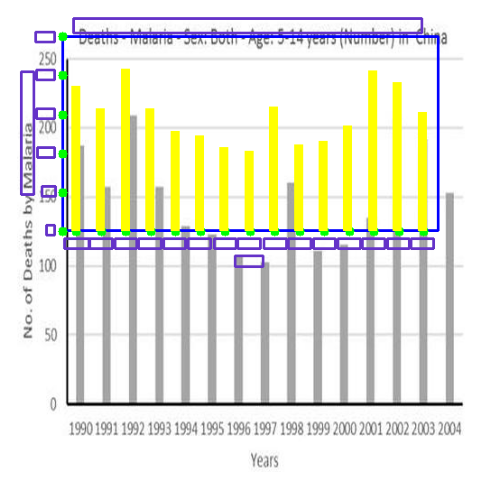

In [27]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path="./temp/0b4dac8d0a28.jpg")

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [28]:
# scaling the corresponding annotation

annotation_resize(ori_image_path=matched_image_path[0],
                  origin_annotation_path=matched_annotation_path[0],
                  saved_path="./temp/0b4dac8d0a28.json")

✅ Image loaded: (512, 512, 3)


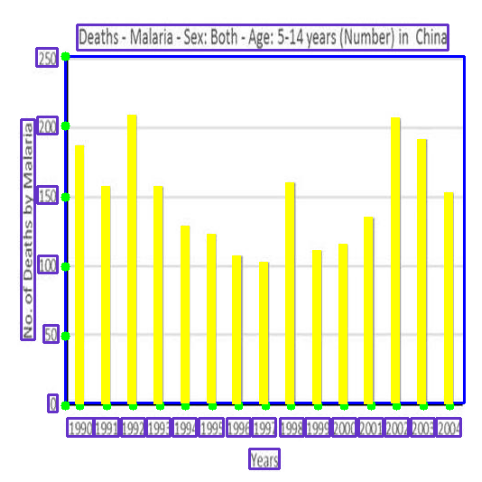

In [29]:
image=image_markable(annotation_path='./temp/0b4dac8d0a28.json',image_path="./temp/0b4dac8d0a28.jpg")

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [30]:
# dot
search_string = "0cfa6023c813"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/raw/train/images/0cfa6023c813.jpg']
['../../../data/raw/train/annotations/0cfa6023c813.json']


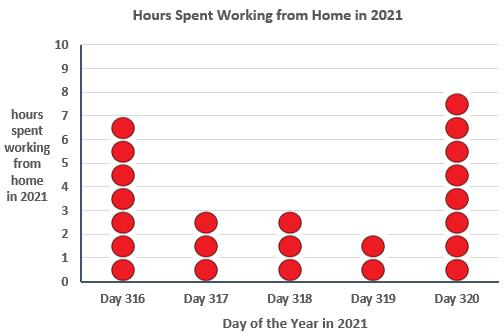

In [31]:
Image.open(fp=matched_image_path[0])

✅ Image loaded: (336, 504, 3)


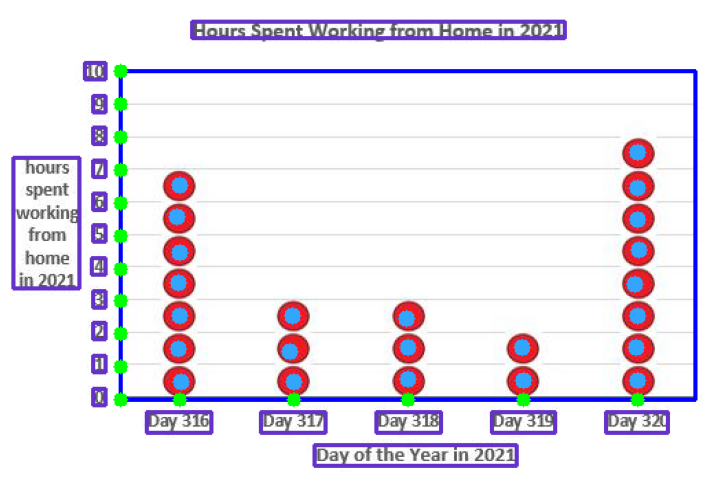

In [32]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

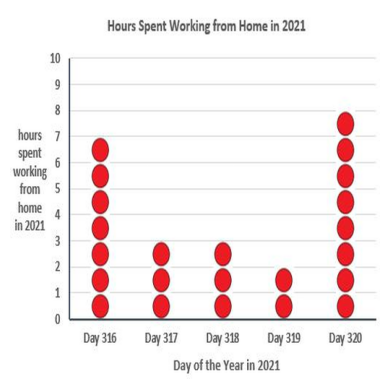

width: 512
height: 512


In [33]:
# resize the raw image to 512, 512
image = Image.open(fp=matched_image_path[0])
resized_image = image.resize(target_size, Image.LANCZOS)

plt.imshow(resized_image)
plt.axis("off")
plt.show()


width,height=resized_image.size
print('width:', width)
print('height:', height)

# tempory store the resized image
resized_image.save("./temp/0cfa6023c813.jpg")

✅ Image loaded: (512, 512, 3)


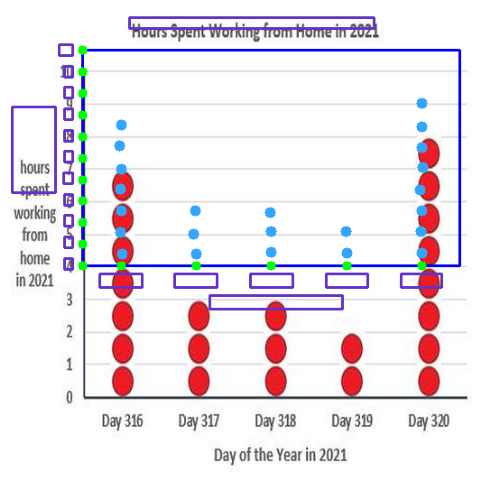

In [34]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path="./temp/0cfa6023c813.jpg")

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [35]:
# scaling the corresponding annotation

annotation_resize(ori_image_path=matched_image_path[0],
                  origin_annotation_path=matched_annotation_path[0],
                  saved_path="./temp/0cfa6023c813.json")

✅ Image loaded: (512, 512, 3)


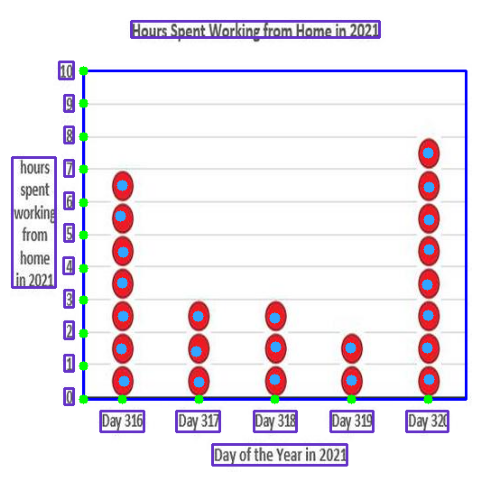

In [36]:
image=image_markable(annotation_path='./temp/0cfa6023c813.json',image_path="./temp/0cfa6023c813.jpg")

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [37]:
# horizontal bar
search_string = "1bd8fa4655f0"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/raw/train/images/1bd8fa4655f0.jpg']
['../../../data/raw/train/annotations/1bd8fa4655f0.json']


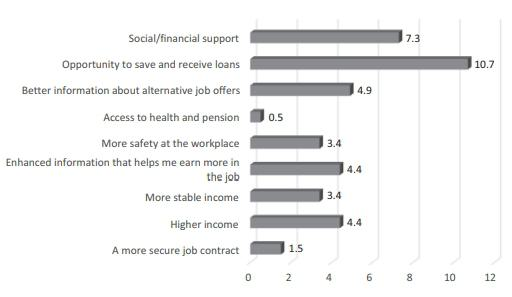

In [38]:
Image.open(fp=matched_image_path[0])

✅ Image loaded: (297, 512, 3)


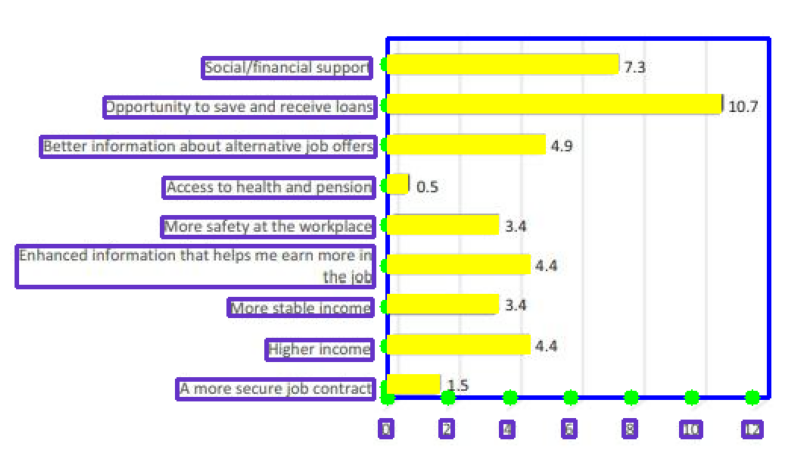

In [39]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

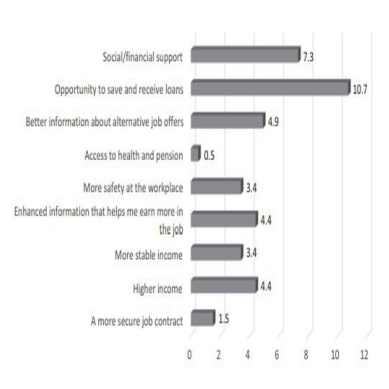

width: 512
height: 512


In [40]:
# resize the raw image to 512, 512
image = Image.open(fp=matched_image_path[0])
resized_image = image.resize(target_size, Image.LANCZOS)

plt.imshow(resized_image)
plt.axis("off")
plt.show()


width,height=resized_image.size
print('width:', width)
print('height:', height)

# tempory store the resized image
resized_image.save("./temp/1bd8fa4655f0.jpg")

✅ Image loaded: (512, 512, 3)


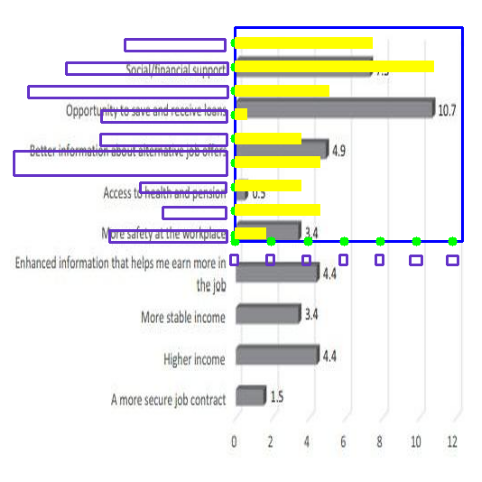

In [41]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path="./temp/1bd8fa4655f0.jpg")

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [42]:
# scaling the corresponding annotation

annotation_resize(ori_image_path=matched_image_path[0],
                  origin_annotation_path=matched_annotation_path[0],
                  saved_path="./temp/1bd8fa4655f0.json")

✅ Image loaded: (512, 512, 3)


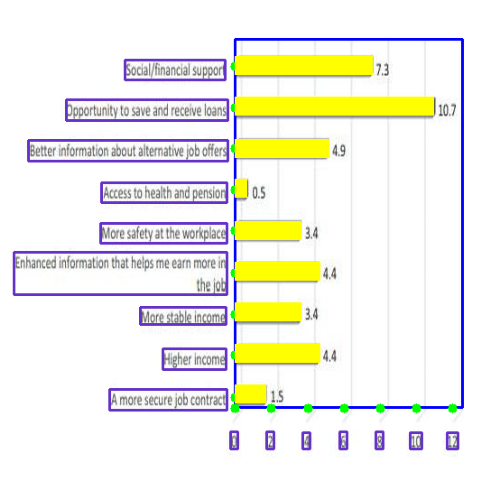

In [43]:
image=image_markable(annotation_path='./temp/1bd8fa4655f0.json',image_path="./temp/1bd8fa4655f0.jpg")

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()